# Analyse RCEMIP — Simulation `large300`
## Transport vertical de la quantité de mouvement par la turbulence convective




## 1. Librairies et constantes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import gc
import os

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

Rd      = 287.05
Rv      = 461.5
EPSILON = Rd / Rv  # ≈ 0.622

DIR_3D = '3D'
DIR_2D = '2D'

def path3d(var):
    return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{var}.nc')

def path2d(var):
    return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{var}.nc')

BLOC = 2

print('Prêt.')


Prêt.


## 2. Lecture des dimensions 

In [3]:
# On ouvre un seul fichier juste pour lire les métadonnées
_ds = xr.open_dataset(path3d('ua'))
_da = _ds['ua']

dim_t = _da.dims[0]
dim_z = _da.dims[1]
dim_y = _da.dims[2]
dim_x = _da.dims[3]
alt    = _da[dim_z].values.copy()   # vecteur altitude 
n_t    = _da.sizes[dim_t]
n_z    = _da.sizes[dim_z]
n_y    = _da.sizes[dim_y]
n_x    = _da.sizes[dim_x]
times  = _da[dim_t].values.copy()

_ds.close()
del _ds, _da
gc.collect()

# Dernier tiers = état stationnaire
t_stat   = int(2 * n_t / 3)
idx_stat = slice(t_stat, None)
n_stat   = n_t - t_stat

time_days = times.astype('float64') //4

print(time_days)

print(f'Grille : {n_t} t  x  {n_z} z  x  {n_y} y  x  {n_x} x')
print(f'Altitude : {alt[0]:.0f} — {alt[-1]:.0f} ')
print(f'État stationnaire : t={t_stat} → {n_t-1}  ({n_stat} pas)')


[ 0.  0.  0.  0.  1.  1.  1.  1.  2.  2.  2.  2.  3.  3.  3.  3.  4.  4.
  4.  4.  5.  5.  5.  5.  6.  6.  6.  6.  7.  7.  7.  7.  8.  8.  8.  8.
  9.  9.  9.  9. 10. 10. 10. 10. 11. 11. 11. 11. 12. 12. 12. 12. 13. 13.
 13. 13. 14. 14. 14. 14. 15. 15. 15. 15. 16. 16. 16. 16. 17. 17. 17. 17.
 18. 18. 18. 18. 19. 19. 19. 19. 20. 20. 20. 20. 21. 21. 21. 21. 22. 22.
 22. 22. 23. 23. 23. 23. 24. 24. 24. 24.]
Grille : 100 t  x  74 z  x  128 y  x  2000 x
Altitude : 0 — 73 
État stationnaire : t=66 → 99  (34 pas)


## 3. PRW et auto-agrégation (fichier 2D natif)


In [4]:
ds_prw  = xr.open_dataset(path2d('prw'))
prw_all = ds_prw['prw'].load()   # (time, y, x) — quelques centaines de Mo max
ds_prw.close()

prw_stat = prw_all.isel({dim_t: idx_stat})
prw_mean = prw_stat.mean(dim=dim_t)         # carte 2D moyenne
prw_flat = prw_mean.values.ravel()  #Met tout en ligne

# Variance spatiale à chaque pas de temps (signal d'agrégation)
prw_var = prw_all.var(dim=[dim_y, dim_x]).values

print(f'PRW chargée. Plage : {prw_flat.min():.1f} — {prw_flat.max():.1f} kg/m²')
print(f'Médiane : {np.median(prw_flat):.1f} kg/m²')


PRW chargée. Plage : 15.5 — 40.5 kg/m²
Médiane : 28.0 kg/m²


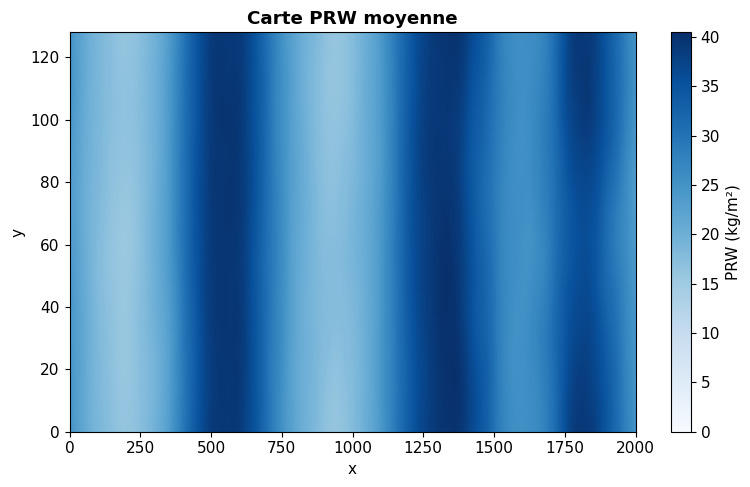

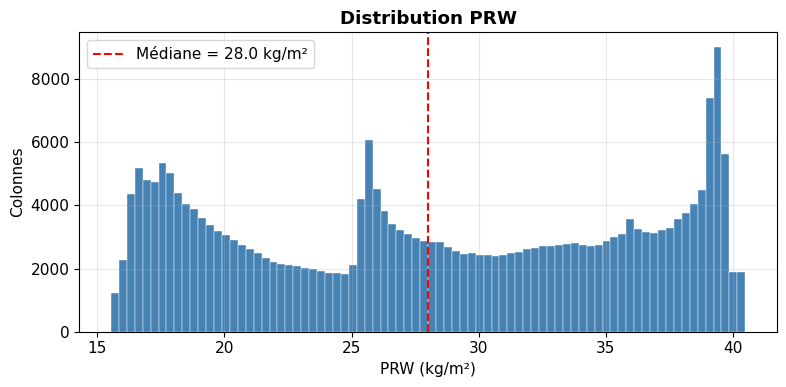

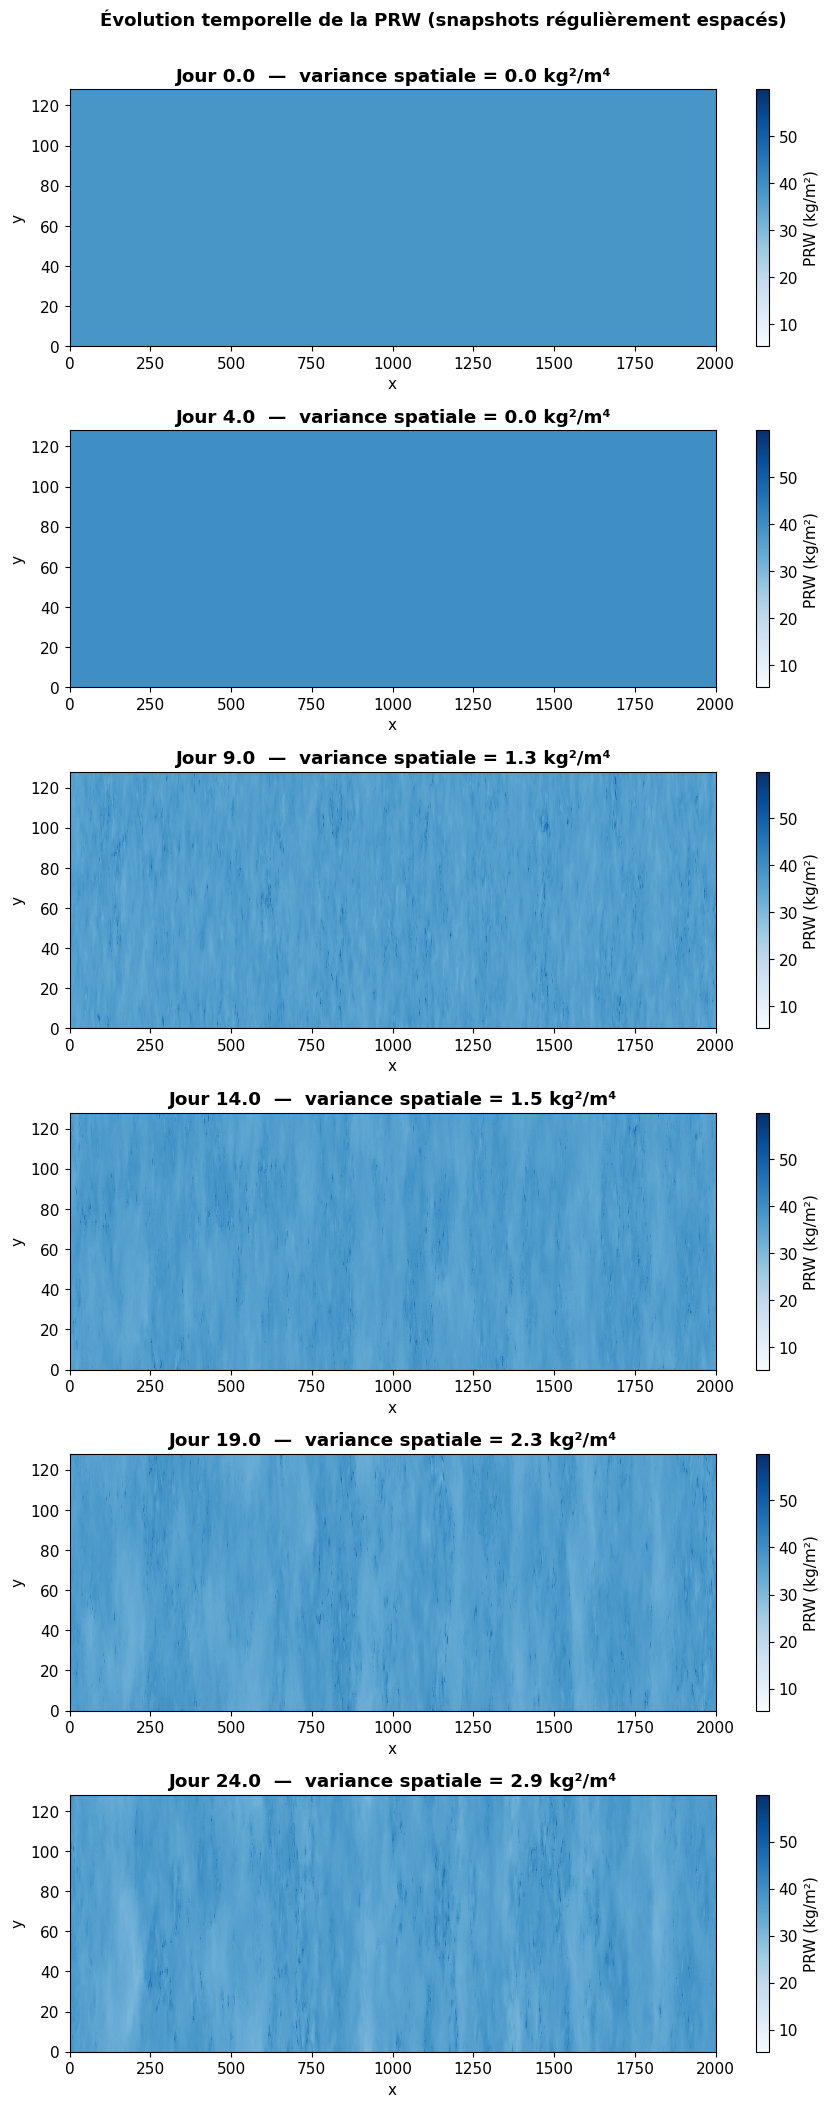

In [5]:
# ======================================================================
# PRW — visualisations empilées
# ======================================================================

# --- 1. Carte 2D PRW moyenne ---
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(prw_mean.values, cmap='Blues', vmin=0)
fig.colorbar(im, ax=ax, label='PRW (kg/m²)')
ax.set_title('Carte PRW moyenne', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
# Pas de set_aspect('equal') : x et y n'ont pas la même résolution/dimension
plt.tight_layout()
plt.show()

# --- 2. Distribution de la PRW ---
fig, ax = plt.subplots(figsize=(8, 4))
med = np.median(prw_flat)
ax.hist(prw_flat, bins=80, color='steelblue', edgecolor='white', lw=0.3)
ax.axvline(med, color='red', lw=1.5, linestyle='--', label=f'Médiane = {med:.1f} kg/m²')
ax.set_xlabel('PRW (kg/m²)')
ax.set_ylabel('Colonnes')
ax.set_title('Distribution PRW', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# PRW — évolution temporelle par tranches
# Objectif : voir comment la structure spatiale de la PRW évolue
# On sélectionne N_TRANCHES instants régulièrement espacés sur toute la simulation
# ======================================================================
N_TRANCHES = 6  # nombre de snapshots à afficher

indices = np.linspace(0, n_t - 1, N_TRANCHES, dtype=int)

# Plage de couleur commune à tous les snapshots pour permettre la comparaison
vmin_prw = float(prw_all.min())
vmax_prw = float(prw_all.max())

fig, axes = plt.subplots(N_TRANCHES, 1, figsize=(9, 3.5 * N_TRANCHES))

for k, it in enumerate(indices):
    ax = axes[k]
    snap = prw_all.isel({dim_t: it}).values  # (ny, nx)
    jour = time_days[it]

    im = ax.pcolormesh(snap, cmap='Blues', vmin=vmin_prw, vmax=vmax_prw)
    fig.colorbar(im, ax=ax, label='PRW (kg/m²)')

    # Indicateur d'agrégation sur ce snapshot
    var_snap = snap.var()
    ax.set_title(f'Jour {jour:.1f}  —  variance spatiale = {var_snap:.1f} kg²/m⁴',
                 fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Évolution temporelle de la PRW (snapshots régulièrement espacés)',
             fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()

## 4. Seuil sec / humide

Seuil : 28.0 kg/m²
Humide : 50.0%   Sec : 50.0%


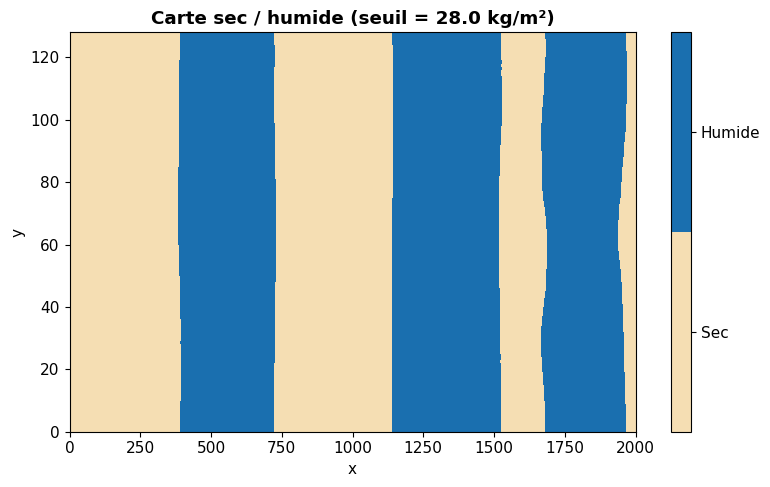

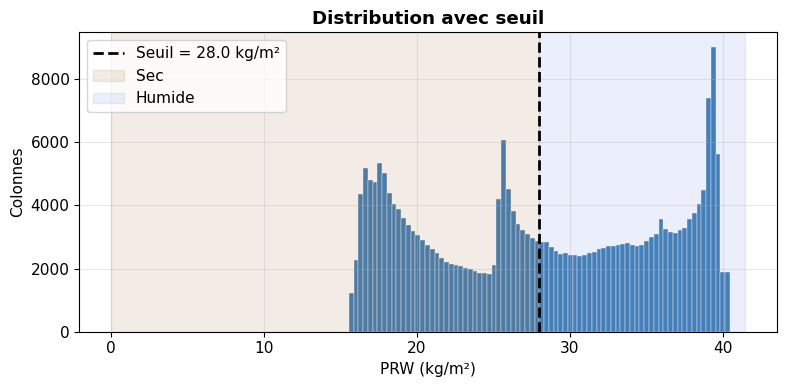

In [6]:
# Ajuster PRW_SEUIL selon le creux de la distribution observée au §3
PRW_SEUIL = float(np.median(prw_flat))
print(f'Seuil : {PRW_SEUIL:.1f} kg/m²')

mh = (prw_mean.values > PRW_SEUIL)   # bool (y, x)
ms = ~mh

print(f'Humide : {mh.mean()*100:.1f}%   Sec : {ms.mean()*100:.1f}%')

# --- Carte sec / humide ---
fig, ax = plt.subplots(figsize=(8, 5))
cmap_sh = mcolors.ListedColormap(['#f5deb3', '#1a6faf'])
im = ax.pcolormesh(mh.astype(int), cmap=cmap_sh, vmin=0, vmax=1)
cbar = fig.colorbar(im, ax=ax, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['Sec', 'Humide'])
ax.set_title(f'Carte sec / humide (seuil = {PRW_SEUIL:.1f} kg/m²)', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

# --- Distribution avec seuil ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prw_flat, bins=80, color='steelblue', edgecolor='white', lw=0.3)
ax.axvline(PRW_SEUIL, color='black', lw=2, linestyle='--',
           label=f'Seuil = {PRW_SEUIL:.1f} kg/m²')
ax.axvspan(0,                    PRW_SEUIL,        alpha=0.1, color='saddlebrown', label='Sec')
ax.axvspan(PRW_SEUIL, prw_flat.max() + 1,          alpha=0.1, color='royalblue',   label='Humide')
ax.set_xlabel('PRW (kg/m²)')
ax.set_ylabel('Colonnes')
ax.set_title('Distribution avec seuil', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Profil ρ₀

On charge `ta`, `pa`, `hus` **séquentiellement** (jamais simultanément)  
en accumulant les sommes nécessaires.


ρ₀ calculé sur 34 pas de temps.
  Surface : 1.183 kg/m³
  ~10 km  : 0.010 kg/m³


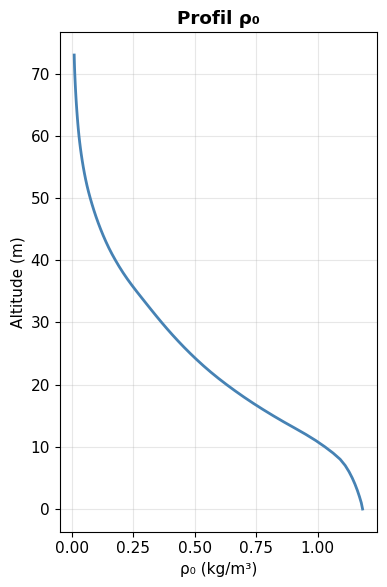

In [7]:
# Accumulation de p et T·(1 + qv/ε)/(1 + qv) = Tv

rho0_sum = np.zeros(n_z)
n_rho    = 0

ds_ta  = xr.open_dataset(path3d('ta')) #température
ds_pa  = xr.open_dataset(path3d('pa'))   #pression
ds_hus = xr.open_dataset(path3d('hus'))  #humidité spécifique

for t0 in range(t_stat, n_t, BLOC):#pour eviter de lire tout d un coup
    t1 = min(t0 + BLOC, n_t)
    sl = {dim_t: slice(t0, t1)}

    T_blk  = ds_ta['ta'].isel(sl).values   # (bloc, z, y, x)
    p_blk  = ds_pa['pa'].isel(sl).values
    qv_blk = ds_hus['hus'].isel(sl).values

    Tv_blk  = T_blk * (1.0 + qv_blk / EPSILON) / (1.0 + qv_blk)  #température virtuelle (formule non approchée)
    rho_blk = p_blk / (Rd * Tv_blk)  #formule des gaz parfait

    rho0_sum += rho_blk.mean(axis=(0, 2, 3)) * (t1 - t0)   #moyenne sur le temps et xy
    n_rho    += (t1 - t0)

    del T_blk, p_blk, qv_blk, Tv_blk, rho_blk
    gc.collect()

ds_ta.close() ; ds_pa.close() ; ds_hus.close()
del ds_ta, ds_pa, ds_hus
gc.collect()

rho0 = rho0_sum / n_rho   # profil 1D [kg/m³]

print(f'ρ₀ calculé sur {n_rho} pas de temps.')
print(f'  Surface : {rho0[0]:.3f} kg/m³')
print(f'  ~10 km  : {rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m³')

fig, ax = plt.subplots(figsize=(4, 6))
ax.plot(rho0, alt, color='steelblue', lw=2)
ax.set_xlabel('ρ₀ (kg/m³)') ; ax.set_ylabel('Altitude (m)')
ax.set_title('Profil ρ₀', fontweight='bold') ; ax.grid(True, alpha=0.3)
plt.tight_layout() ; plt.show()


## 6. Profil du vent horizontal moyen

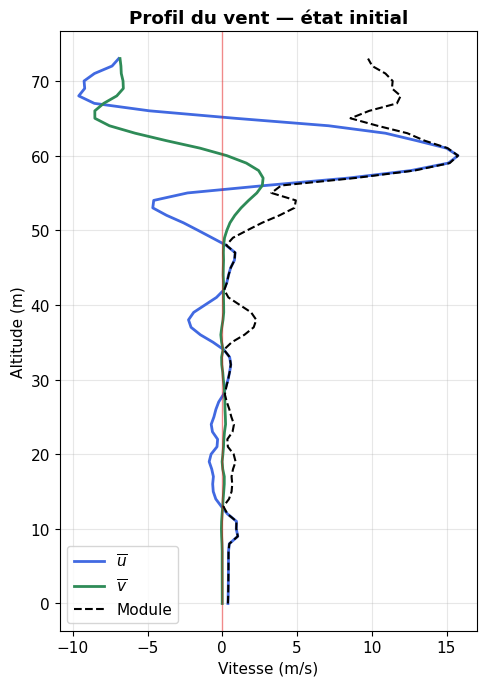

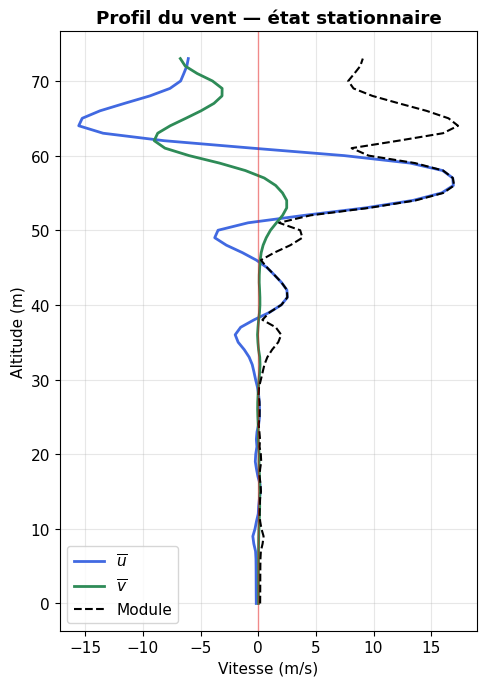

In [8]:
def calc_profil_vent(idx_slice):
    """Charge u et v séquentiellement, calcule le profil moyen."""
    ds_u = xr.open_dataset(path3d('ua'))
    u_m = ds_u['ua'].isel({dim_t: idx_slice}).mean(dim=[dim_t, dim_y, dim_x]).values
    ds_u.close()
    gc.collect()

    ds_v = xr.open_dataset(path3d('va'))
    v_m = ds_v['va'].isel({dim_t: idx_slice}).mean(dim=[dim_t, dim_y, dim_x]).values
    ds_v.close()
    gc.collect()

    return u_m, v_m

def plot_profil_vent(u_m, v_m, titre):
    fig, ax = plt.subplots(figsize=(5, 7))
    ax.plot(u_m,                       alt, color='royalblue', lw=2, label=r'$\overline{u}$')
    ax.plot(v_m,                       alt, color='seagreen',  lw=2, label=r'$\overline{v}$')
    ax.plot(np.sqrt(u_m**2 + v_m**2),  alt, 'k--', lw=1.5,         label='Module')
    ax.axvline(0, color='red', alpha=0.4, lw=1)
    ax.set_xlabel('Vitesse (m/s)') ; ax.set_ylabel('Altitude (m)')
    ax.set_title(titre, fontweight='bold') ; ax.grid(True, alpha=0.3) ; ax.legend()
    plt.tight_layout() ; plt.show()

u_init, v_init = calc_profil_vent(slice(0, 5))
plot_profil_vent(u_init, v_init, 'Profil du vent — état initial')

u_fin, v_fin = calc_profil_vent(idx_stat)
plot_profil_vent(u_fin, v_fin, 'Profil du vent — état stationnaire')


En dessous de la tropopause — les flux s'annulent
Dans la troposphère, la convection génère des ondes de gravité qui se propagent vers le haut. Ces ondes transportent du flux de QdM u′w′. Mais la troposphère est un milieu qui favorise les allers-retours : une onde monte, atteint un niveau où elle est réfléchie (par exemple là où sa fréquence dépasse la fréquence de Brunt-Väisälä locale), redescend, remonte, etc. Au bout d'un moment la moyenne temporelle de u′w′ s'annule parce que l'onde transporte autant vers le haut que vers le bas. C'est ça l'instabilité dont on t'a parlé — plus précisément c'est la résonance des ondes dans la cavité troposphérique.

À la tropopause — un filtre
La tropopause est une barrière dynamique forte : la stabilité statique augmente brutalement (on passe de la troposphère convective à la stratosphère très stable). Les ondes qui n'ont pas assez d'énergie pour franchir cette barrière sont réfléchies vers le bas et continuent leurs allers-retours dans la troposphère — leur contribution nette à u′w′ reste nulle.
Seules les ondes avec suffisamment d'énergie percent la tropopause et se propagent vers le haut en stratosphère. Celles-là ne reviennent jamais — il n'y a plus de réflexion pour les renvoyer vers le bas. Leur flux u′w′ est donc unilatéral et non compensé.

Ce qui amène le vent non nul en haut
C'est là la question clé. Les ondes qui ont percé la tropopause transportent du flux u′w′ vers le haut, et quand elles déferlent (comme une vague sur une plage) à une certaine altitude en stratosphère, elles déposent leur QdM dans le vent moyen. Le déferlement se produit quand l'amplitude de l'onde devient trop grande par rapport à la densité locale — or la densité diminue avec l'altitude, donc une onde d'amplitude constante va inevitablement déferler à un moment.
Ce dépôt de QdM par déferlement d'ondes s'appelle le forçage d'Eliassen-Palm et c'est précisément ce qui accélère ou décélère le vent moyen en stratosphère. Le vent que tu observes à iz=73 est le résultat de l'accumulation de ces dépôts au cours de la simulation.

## 7. Bilan de QdM global

**Stratégie clé :** on ne charge jamais `u` et `w` ensemble.  
On calcule la covariance ⟨u′w′⟩ **niveau par niveau** :  
pour chaque niveau z, on extrait la tranche 2D (y, x) de u et de w,  
on calcule les anomalies, puis le produit. La tranche 2D est ~100× plus petite  
que le tableau 4D complet.

$$\text{Flux}(z) = \rho_0(z)\,\overline{u'w'}(z) = \rho_0(z) \cdot \frac{1}{N_t N_x N_y}\sum_{t,x,y} u'(t,z,x,y)\,w'(t,z,x,y)$$


In [9]:
# ======================================================================
# Calcul niveau par niveau pour minimiser la RAM
# Pour chaque niveau z :
#   - on lit la tranche u[:, z, :, :] et w[:, z, :, :] sur l'état stationnaire
#   - on calcule u' * w' et on moyenne sur (t, y, x)
# ======================================================================

flux_uw = np.zeros(n_z)   # ρ₀ <u'w'>  [kg m⁻¹ s⁻²]
flux_vw = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):
    # Tranche (t_stat, y, x) pour ce niveau
    u_lev = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values  # (n_stat, ny, nx)
    w_lev = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values

    # Anomalies spatiales (décomposition de Reynolds)
    u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    flux_uw[iz] = rho0[iz] * (u_p * w_p).mean()

    del u_lev, w_lev, u_p, w_p

    # v'w' au même niveau
    v_lev = ds_v['va'].isel({dim_t: idx_stat, dim_z: iz}).values
    w_lev = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values
    v_p = v_lev - v_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    flux_vw[iz] = rho0[iz] * (v_p * w_p).mean()

    del v_lev, w_lev, v_p, w_p
    gc.collect()

    if iz % 10 == 0:
        print(f'  Niveau {iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_v.close() ; ds_w.close()
del ds_u, ds_v, ds_w
gc.collect()

print('Flux globaux calculés.')


  Niveau 0/73  (0 m)
  Niveau 10/73  (10 m)
  Niveau 20/73  (20 m)
  Niveau 30/73  (30 m)
  Niveau 40/73  (40 m)
  Niveau 50/73  (50 m)
  Niveau 60/73  (60 m)
  Niveau 70/73  (70 m)
Flux globaux calculés.


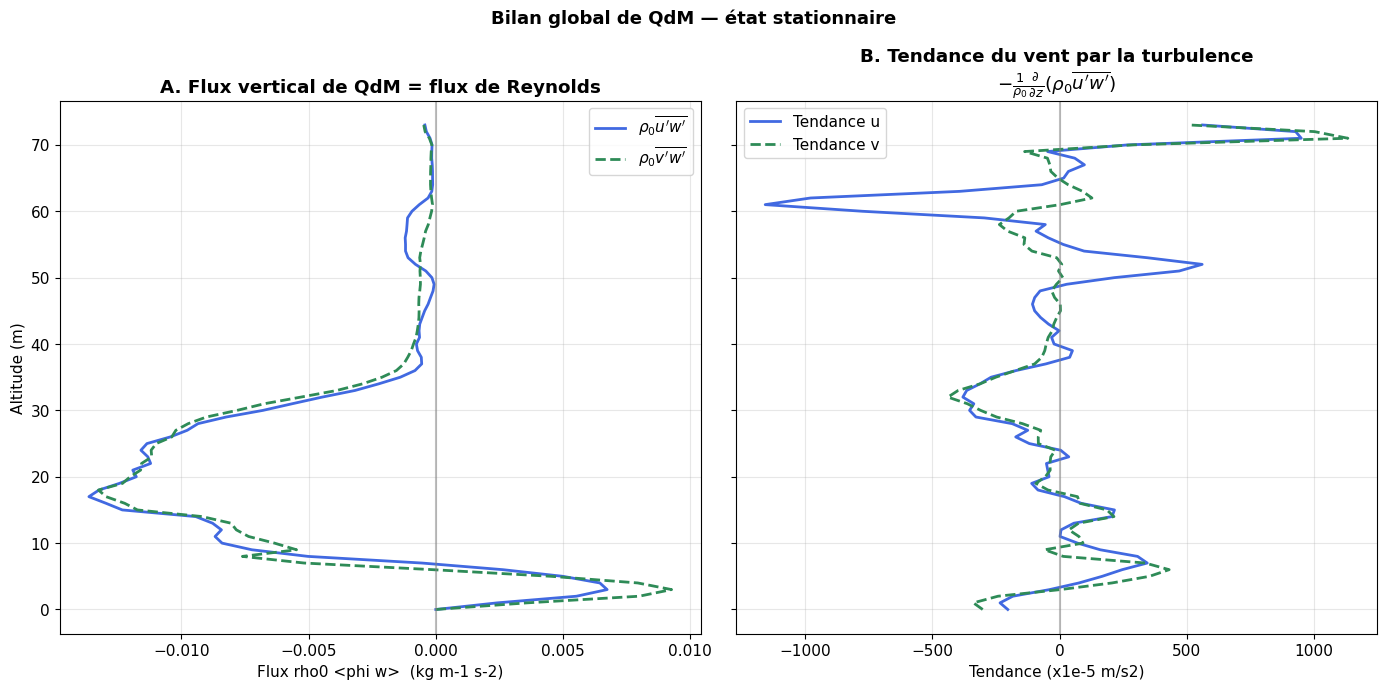

In [10]:
def tendance(flux_profil):
    """Force de Reynolds : -1/rho0 · d(rho0 <phi'w'>) / dz"""
    return -np.gradient(flux_profil, alt) / rho0

tend_u_glob = tendance(flux_uw)
tend_v_glob = tendance(flux_vw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

ax1.plot(flux_uw, alt, color='royalblue', lw=2, label=r"$\rho_0\overline{u'w'}$")
ax1.plot(flux_vw, alt, color='seagreen',  lw=2, linestyle='--', label=r"$\rho_0\overline{v'w'}$")
ax1.axvline(0, color='grey', alpha=0.5)
ax1.set_xlabel('Flux rho0 <phi w>  (kg m-1 s-2)')
ax1.set_ylabel('Altitude (m)')
ax1.set_title('A. Flux vertical de QdM = flux de Reynolds', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

titre_b = (
    "B. Tendance du vent par la turbulence\n"
    r"$-\frac{1}{\rho_0}\frac{\partial}{\partial z}(\rho_0\overline{u'w'})$"
)
ax2.plot(tend_u_glob * 1e5, alt, color='royalblue', lw=2, label='Tendance u')
ax2.plot(tend_v_glob * 1e5, alt, color='seagreen',  lw=2, linestyle='--', label='Tendance v')
ax2.axvline(0, color='grey', alpha=0.5)
ax2.set_xlabel('Tendance (x1e-5 m/s2)')
ax2.set_title(titre_b, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Bilan global de QdM — état stationnaire', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Bilan conditionnel — décomposition par régime turbulent

Même stratégie niveau par niveau, mais on a besoin de `w`, `u`, `clw`, `cli`  
pour les masques. On les lit **séquentiellement** pour chaque niveau.

| Régime | Condition |
|--------|-----------|
| Convection nuageuse | w′ > +SEUIL_W et qc > SEUIL_QC |
| Thermiques secs | w′ > +SEUIL_W et qc ≤ SEUIL_QC |
| Subsidence = mouvement vertical descendant | w′ < −SEUIL_W |
| Petite turbulence | résidu |


In [11]:
SEUIL_W  = 0.05   # m/s
SEUIL_QC = 1e-5   # kg/kg

flux_conv = np.zeros(n_z)
flux_sec  = np.zeros(n_z)
flux_sub  = np.zeros(n_z)
flux_tot_cond = np.zeros(n_z)

ds_u   = xr.open_dataset(path3d('ua'))
ds_w   = xr.open_dataset(path3d('wa'))
ds_clw = xr.open_dataset(path3d('clw'))
ds_cli = xr.open_dataset(path3d('cli'))

for iz in range(n_z):
    sl = {dim_t: idx_stat, dim_z: iz}

    u_lev   = ds_u['ua'].isel(sl).values    # (n_stat, ny, nx)
    w_lev   = ds_w['wa'].isel(sl).values
    clw_lev = ds_clw['clw'].isel(sl).values
    cli_lev = ds_cli['cli'].isel(sl).values

    u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    qc  = clw_lev + cli_lev

    flux_loc = rho0[iz] * u_p * w_p   # (n_stat, ny, nx)

    m_conv = (w_p >  SEUIL_W) & (qc >  SEUIL_QC)
    m_sec  = (w_p >  SEUIL_W) & (qc <= SEUIL_QC)
    m_sub  = (w_p < -SEUIL_W)

    flux_conv[iz]     = np.where(m_conv, flux_loc, 0.0).mean()
    flux_sec[iz]      = np.where(m_sec,  flux_loc, 0.0).mean()
    flux_sub[iz]      = np.where(m_sub,  flux_loc, 0.0).mean()
    flux_tot_cond[iz] = flux_loc.mean()

    del u_lev, w_lev, clw_lev, cli_lev, u_p, w_p, qc, flux_loc
    del m_conv, m_sec, m_sub
    gc.collect()

    if iz % 10 == 0:
        print(f'  Niveau {iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close() ; ds_clw.close() ; ds_cli.close()
del ds_u, ds_w, ds_clw, ds_cli
gc.collect()

flux_rest_cond = flux_tot_cond - (flux_conv + flux_sec + flux_sub)

print('Flux conditionnels calculés.')


  Niveau 0/73  (0 m)
  Niveau 10/73  (10 m)
  Niveau 20/73  (20 m)
  Niveau 30/73  (30 m)
  Niveau 40/73  (40 m)
  Niveau 50/73  (50 m)
  Niveau 60/73  (60 m)
  Niveau 70/73  (70 m)
Flux conditionnels calculés.


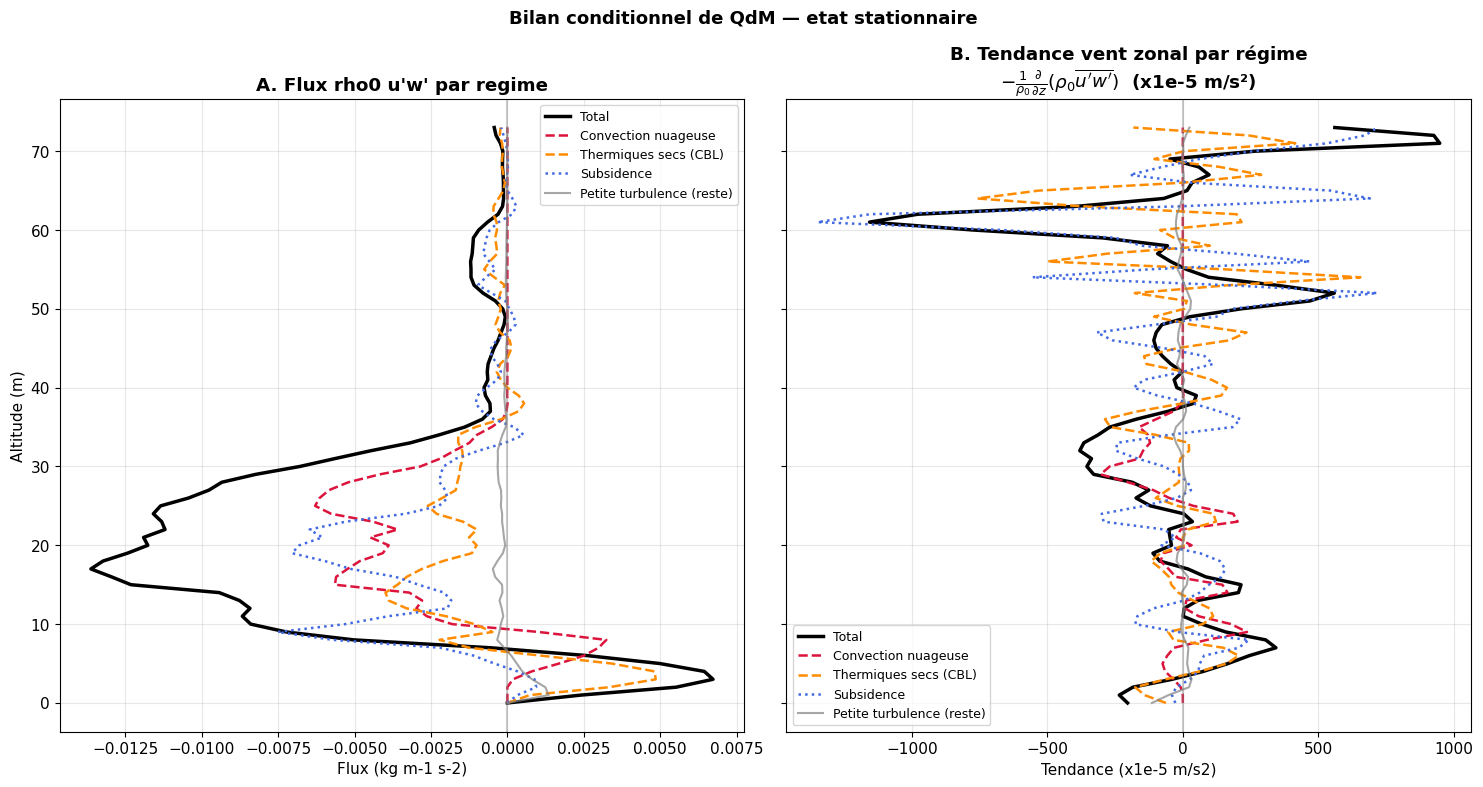

In [12]:
tend_conv = tendance(flux_conv)
tend_sec  = tendance(flux_sec)
tend_sub  = tendance(flux_sub)
tend_rest = tendance(flux_rest_cond)
tend_tot  = tendance(flux_tot_cond)

kw = dict(tot  = dict(color='black',      lw=2.5),
          conv = dict(color='crimson',    lw=1.8, linestyle='--'),
          sec  = dict(color='darkorange', lw=1.8, linestyle='--'),
          sub  = dict(color='royalblue',  lw=1.8, linestyle=':'),
          rest = dict(color='grey',       lw=1.5, alpha=0.7))

titre_b = (
    "B. Tendance vent zonal par régime\n"
    r"$-\frac{1}{\rho_0}\frac{\partial}{\partial z}(\rho_0\overline{u'w'})$"
    "  (x1e-5 m/s²)"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

ax1.plot(flux_tot_cond,  alt, label='Total',                    **kw['tot'])
ax1.plot(flux_conv,      alt, label='Convection nuageuse',       **kw['conv'])
ax1.plot(flux_sec,       alt, label='Thermiques secs (CBL)',     **kw['sec'])
ax1.plot(flux_sub,       alt, label='Subsidence',                **kw['sub'])
ax1.plot(flux_rest_cond, alt, label='Petite turbulence (reste)', **kw['rest'])
ax1.axvline(0, color='grey', alpha=0.4)
ax1.set_title('A. Flux rho0 u\'w\' par regime', fontweight='bold')
ax1.set_xlabel('Flux (kg m-1 s-2)')
ax1.set_ylabel('Altitude (m)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

sc = 1e5
ax2.plot(tend_tot  * sc, alt, label='Total',                    **kw['tot'])
ax2.plot(tend_conv * sc, alt, label='Convection nuageuse',       **kw['conv'])
ax2.plot(tend_sec  * sc, alt, label='Thermiques secs (CBL)',     **kw['sec'])
ax2.plot(tend_sub  * sc, alt, label='Subsidence',                **kw['sub'])
ax2.plot(tend_rest * sc, alt, label='Petite turbulence (reste)', **kw['rest'])
ax2.axvline(0, color='grey', alpha=0.4)
ax2.set_title(titre_b, fontweight='bold')
ax2.set_xlabel('Tendance (x1e-5 m/s2)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Bilan conditionnel de QdM — etat stationnaire', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Bilan de QdM par région (sec / humide)

  Niveau 0/73
  Niveau 10/73
  Niveau 20/73
  Niveau 30/73
  Niveau 40/73
  Niveau 50/73
  Niveau 60/73
  Niveau 70/73


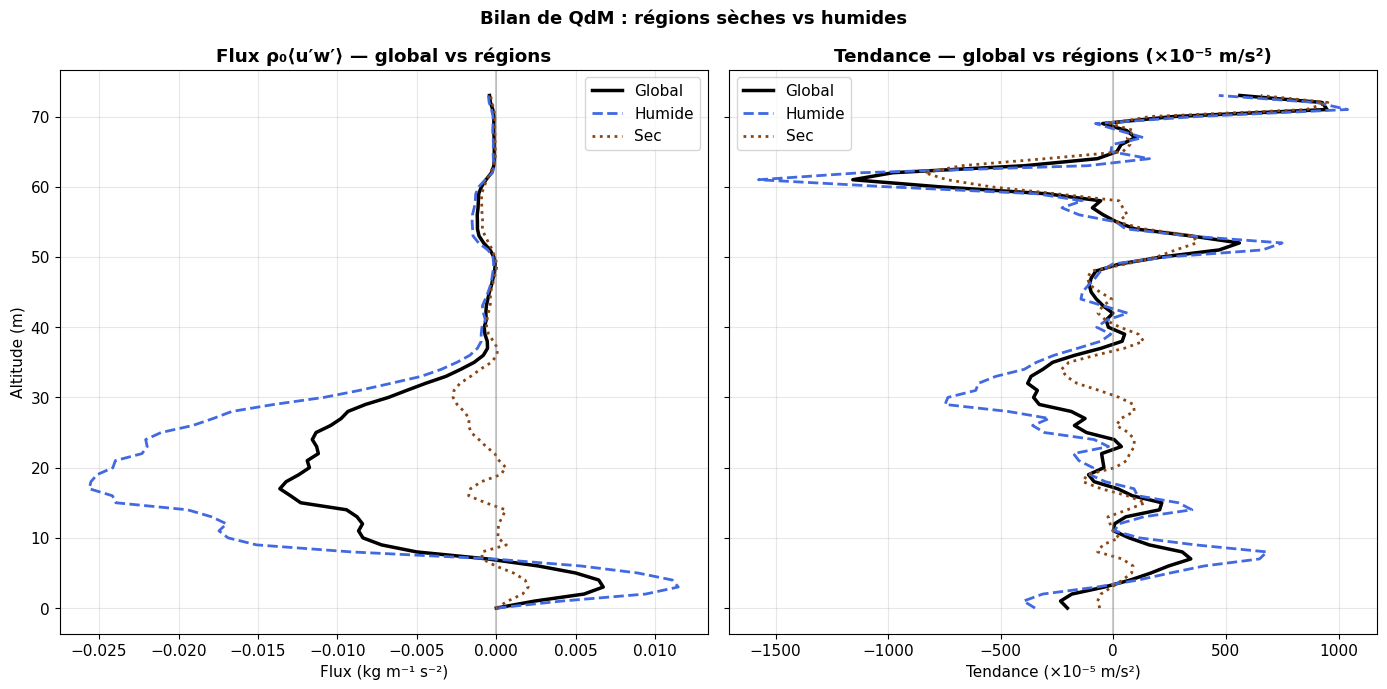

In [13]:
flux_h = np.zeros(n_z)
flux_s = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):
    sl = {dim_t: idx_stat, dim_z: iz}

    u_lev = ds_u['ua'].isel(sl).values   # (n_stat, ny, nx)
    w_lev = ds_w['wa'].isel(sl).values

    u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    flux_loc = rho0[iz] * u_p * w_p   # (n_stat, ny, nx)

    # mh / ms sont des masques 2D (ny, nx) construits tout ne haut (représentation des colonnes)
    # on les broadcast sur l'axe temps
    flux_h[iz] = flux_loc[:, mh].mean()
    flux_s[iz] = flux_loc[:, ms].mean()

    del u_lev, w_lev, u_p, w_p, flux_loc
    gc.collect()

    if iz % 10 == 0:
        print(f'  Niveau {iz}/{n_z-1}')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

tend_h = tendance(flux_h)
tend_s = tendance(flux_s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

ax1.plot(flux_uw, alt, 'k-',  lw=2.5, label='Global')
ax1.plot(flux_h,  alt, color='royalblue',   lw=2, linestyle='--', label='Humide')
ax1.plot(flux_s,  alt, color='saddlebrown', lw=2, linestyle=':',  label='Sec')
ax1.axvline(0, color='grey', alpha=0.4)
ax1.set_title('Flux ρ₀⟨u′w′⟩ — global vs régions', fontweight='bold')
ax1.set_xlabel('Flux (kg m⁻¹ s⁻²)') ; ax1.set_ylabel('Altitude (m)')
ax1.legend() ; ax1.grid(True, alpha=0.3)

ax2.plot(tend_u_glob * 1e5, alt, 'k-',  lw=2.5, label='Global')
ax2.plot(tend_h * 1e5,      alt, color='royalblue',   lw=2, linestyle='--', label='Humide')
ax2.plot(tend_s * 1e5,      alt, color='saddlebrown', lw=2, linestyle=':',  label='Sec')
ax2.axvline(0, color='grey', alpha=0.4)
ax2.set_title('Tendance — global vs régions (×10⁻⁵ m/s²)', fontweight='bold')
ax2.set_xlabel('Tendance (×10⁻⁵ m/s²)')
ax2.legend() ; ax2.grid(True, alpha=0.3)

plt.suptitle('Bilan de QdM : régions sèches vs humides', fontsize=13, fontweight='bold')
plt.tight_layout() ; plt.show()


## 10. Évolution temporelle du flux de Reynolds intégré

On intègre ρ₀⟨u′w′⟩ verticalement (0–15 km) à chaque pas de temps.  
Ici on traite **un pas de temps à la fois** — un seul niveau de mémoire.


  t=0/99
  t=20/99
  t=40/99
  t=60/99
  t=80/99


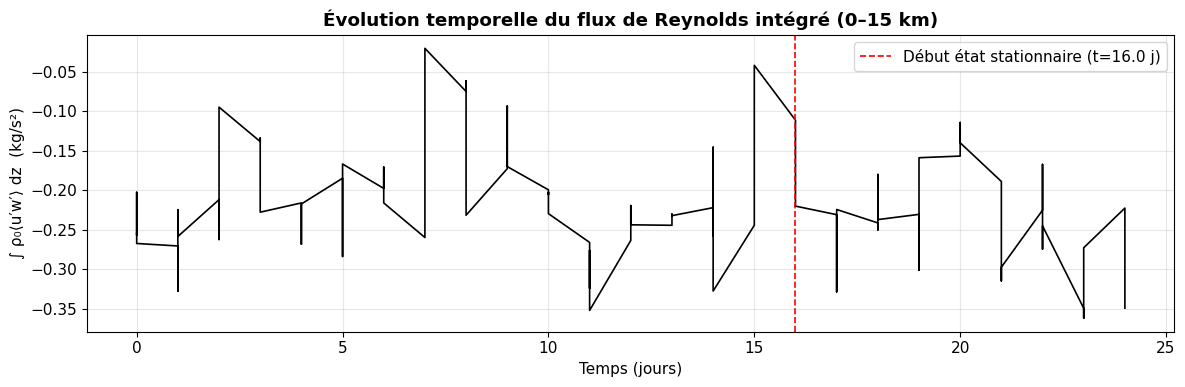

In [14]:
idx_tropo = np.searchsorted(alt, 15000)
alt_tropo = alt[:idx_tropo]
rho0_tropo = rho0[:idx_tropo]

flux_int_time = np.zeros(n_t)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for it in range(n_t):
    sl = {dim_t: it}

    u_t = ds_u['ua'].isel(sl).values   # (z, ny, nx)
    w_t = ds_w['wa'].isel(sl).values

    u_p = u_t - u_t.mean(axis=(1, 2), keepdims=True)
    w_p = w_t - w_t.mean(axis=(1, 2), keepdims=True)

    # Flux moyen horizontal à chaque niveau, intégré verticalement
    flux_prof = (rho0[:, None, None] * u_p * w_p).mean(axis=(1, 2))  # (z,)
    flux_int_time[it] = np.trapz(flux_prof[:idx_tropo], alt_tropo)

    del u_t, w_t, u_p, w_p, flux_prof
    if it % 20 == 0:
        gc.collect()
        print(f'  t={it}/{n_t-1}')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_days, flux_int_time, color='black', lw=1.2)
ax.axvline(time_days[t_stat], color='red', lw=1.2, linestyle='--',
           label=f'Début état stationnaire (t={time_days[t_stat]:.1f} j)')
ax.set_xlabel('Temps (jours)') ; ax.set_ylabel('∫ ρ₀⟨u′w′⟩ dz  (kg/s²)')
ax.set_title('Évolution temporelle du flux de Reynolds intégré (0–15 km)', fontweight='bold')
ax.legend() ; ax.grid(True, alpha=0.3)
plt.tight_layout() ; plt.show()


## 12. Carte 2D du flux moyen (dans le temps) du flux de Reynolds 

On visualise la carte (x, y) de ρ₀ u′w′ au niveau le plus bas du modèle  
(premier niveau au-dessus de la surface), superposée au contour du masque humide.  
Cela montre directement si le transport de QdM est localisé dans les zones convectives.


In [15]:
import xarray as xr
ds = xr.open_dataset(path3d('ua'))
print(ds)
dime_z=ds['ua'].dims[1]
print(ds[dime_z].attrs)

<xarray.Dataset> Size: 8GB
Dimensions:  (time: 100, altitude: 74, y: 128, x: 2000)
Dimensions without coordinates: time, altitude, y, x
Data variables:
    ua       (time, altitude, y, x) float32 8GB ...
{}


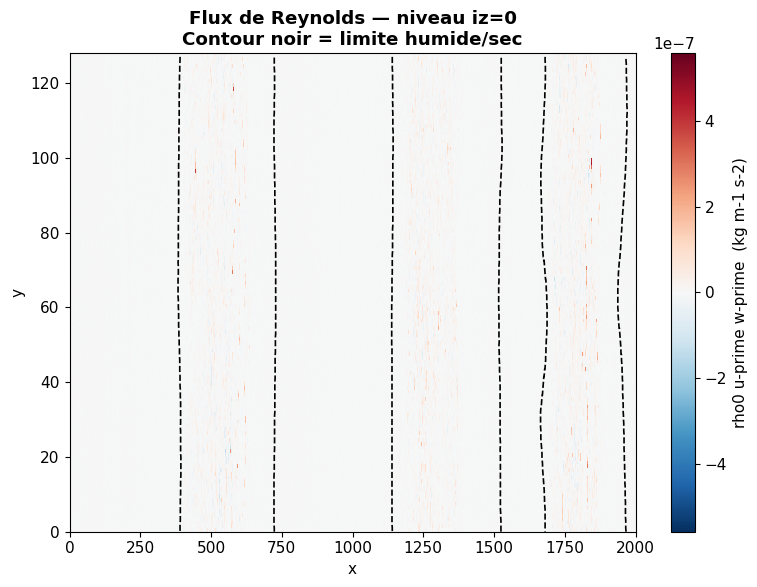

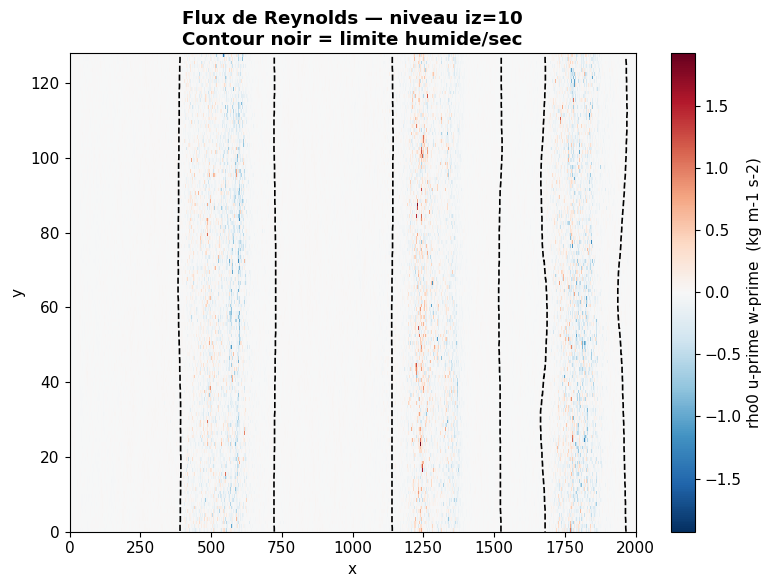

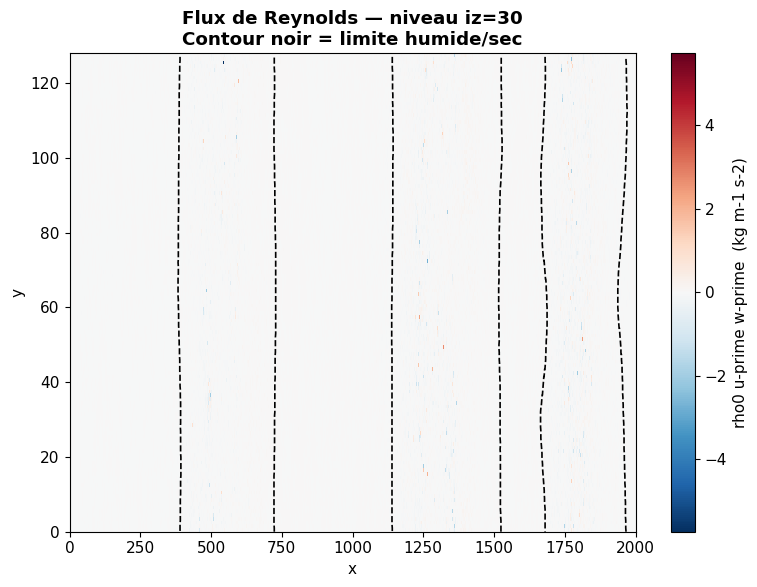

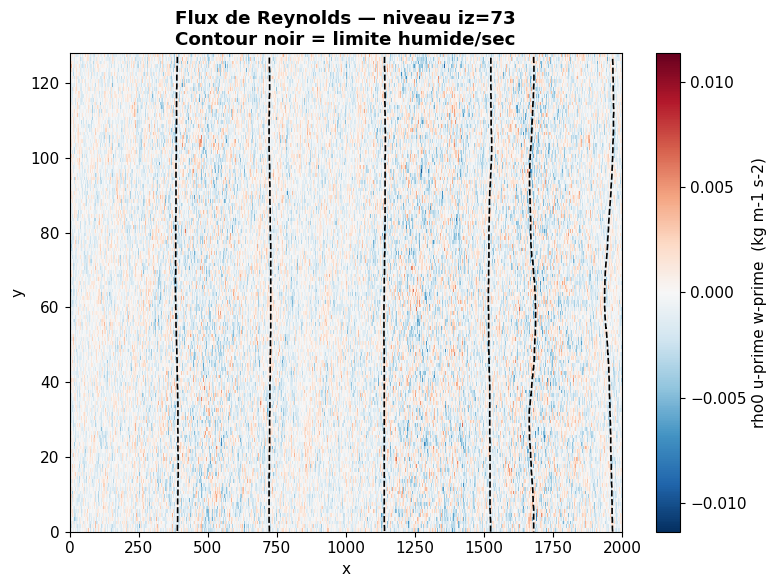

In [16]:
for iz in [0, 10, 30, 73]:
    ds_u = xr.open_dataset(path3d('ua'))
    ds_w = xr.open_dataset(path3d('wa'))

    sl = {dim_t: idx_stat, dim_z: iz}
    u_lev = ds_u['ua'].isel(sl).values   # (n_stat, ny, nx)
    w_lev = ds_w['wa'].isel(sl).values

    ds_u.close() ; ds_w.close()
    del ds_u, ds_w
    gc.collect()

    u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    flux_2d = (rho0[iz] * u_p * w_p).mean(axis=0)   # (ny, nx)

    del u_lev, w_lev, u_p, w_p
    gc.collect()

    fig, ax = plt.subplots(figsize=(8, 6))
    vmax = np.abs(flux_2d).max()
    im = ax.pcolormesh(flux_2d, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, label='rho0 u-prime w-prime  (kg m-1 s-2)')
    ax.contour(mh.astype(float), levels=[0.5], colors='black',
               linewidths=1.2, linestyles='--')
    ax.set_title(f'Flux de Reynolds — niveau iz={iz}\n'
                 f'Contour noir = limite humide/sec',
                 fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()

## Dérivée temporelle du vent à plusieurs niveaux en milieu de simulation

In [17]:
# ======================================================================
# §13 — Configuration commune
# ======================================================================

IZ_LEVELS = [0, 10, 30, 73]   # mêmes niveaux que §12

# Indice central de l'état stationnaire
it_mid = t_stat + n_stat // 2
it_a   = it_mid
it_b   = it_mid + 1

# dt en secondes
dt_days = float(time_days[it_b] - time_days[it_a])
dt_sec  = dt_days * 86400.0
it_c    = it_mid   # pas de temps unique pour advection et pression
print(f'dt utilisé pour ∂u/∂t : {dt_sec:.0f} s  ({dt_days:.4f} j)')

# Résolution horizontale (inférée depuis les coordonnées, sinon 2 km par défaut)
try:
    _ds2 = xr.open_dataset(path3d('ua'))
    _xv  = _ds2['ua'][dim_x].values
    _yv  = _ds2['ua'][dim_y].values
    dx   = float(np.mean(np.diff(_xv)))
    dy   = float(np.mean(np.diff(_yv)))
    _ds2.close() ; del _ds2, _xv, _yv
    if abs(dx) <= 1.5:   # coordonnées = indices entiers → on force la vraie résolution
        dx = 2000.0 ; dy = 2000.0
except Exception:
    dx = 2000.0 ; dy = 2000.0
print(f'Résolution horizontale : dx={dx:.0f} m  dy={dy:.0f} m')


dt utilisé pour ∂u/∂t : 86400 s  (1.0000 j)
Résolution horizontale : dx=2000 m  dy=2000 m


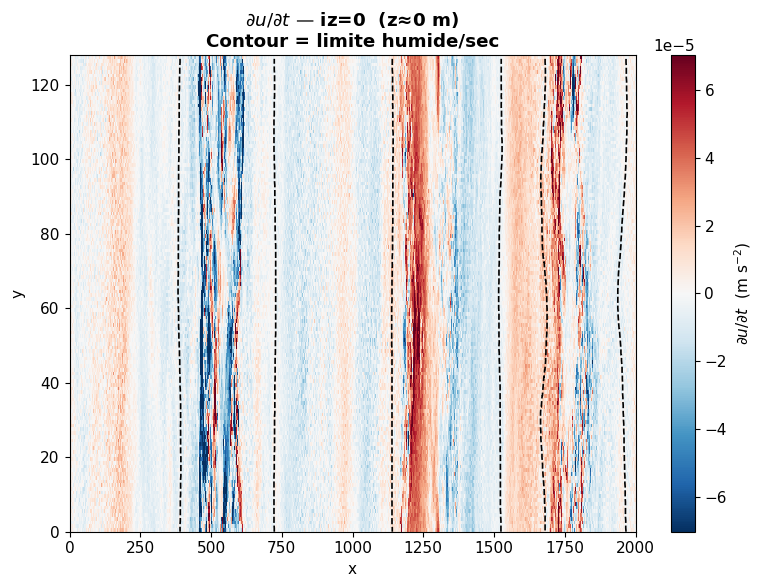

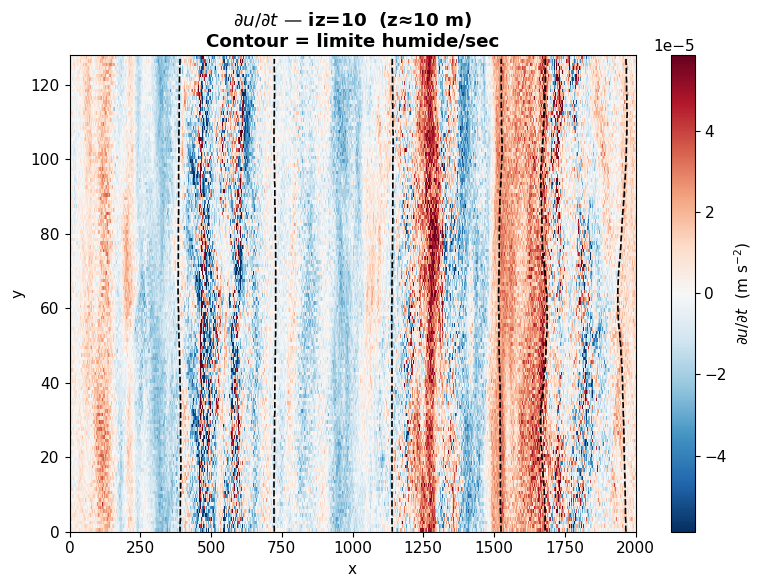

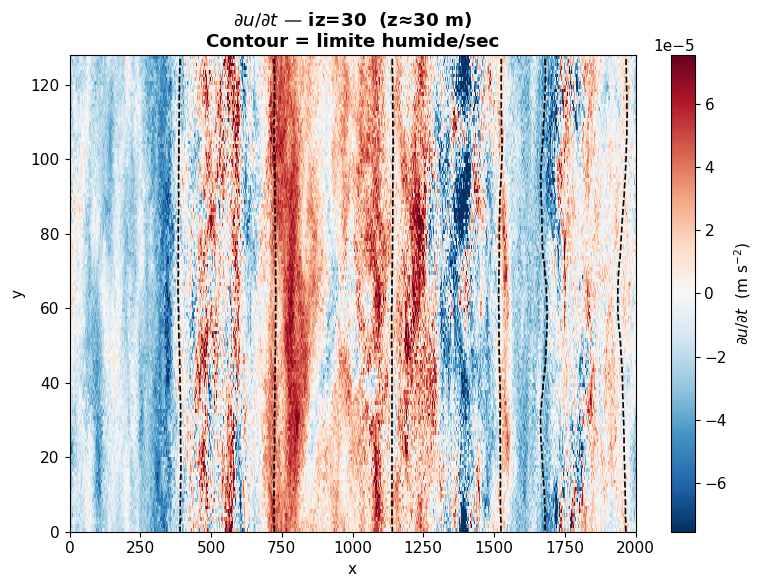

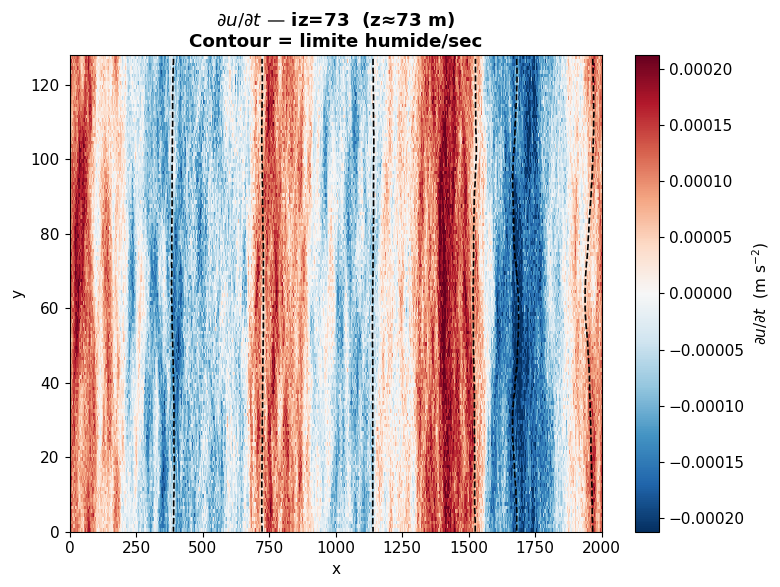

§13.1 ∂u/∂t terminé.


In [18]:
# ======================================================================
# §13.1 — Terme ∂u/∂t  (différence finie temporelle)
# ======================================================================

ds_u = xr.open_dataset(path3d('ua'))

for iz in IZ_LEVELS:
    u_a = ds_u['ua'].isel({dim_t: it_a, dim_z: iz}).values   # (ny, nx)
    u_b = ds_u['ua'].isel({dim_t: it_b, dim_z: iz}).values

    dudt_2d = (u_b - u_a) / dt_sec   # m/s²
    del u_a, u_b ; gc.collect()

    fig, ax = plt.subplots(figsize=(8, 6))
    vmax = np.percentile(np.abs(dudt_2d), 99)
    if vmax == 0: vmax = 1e-9
    im = ax.pcolormesh(dudt_2d, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, label=r'$\partial u/\partial t$  (m s$^{-2}$)')
    ax.contour(mh.astype(float), levels=[0.5], colors='black',
               linewidths=1.2, linestyles='--')
    ax.set_title(
        rf'$\partial u / \partial t$ — iz={iz}  (z≈{alt[iz]:.0f} m)'
        '\nContour = limite humide/sec', fontweight='bold')
    ax.set_xlabel('x') ; ax.set_ylabel('y')
    plt.tight_layout() ; plt.show()
    del dudt_2d

ds_u.close() ; del ds_u ; gc.collect()
print('§13.1 ∂u/∂t terminé.')


## Terme d'advection à plusieurs niveaux 

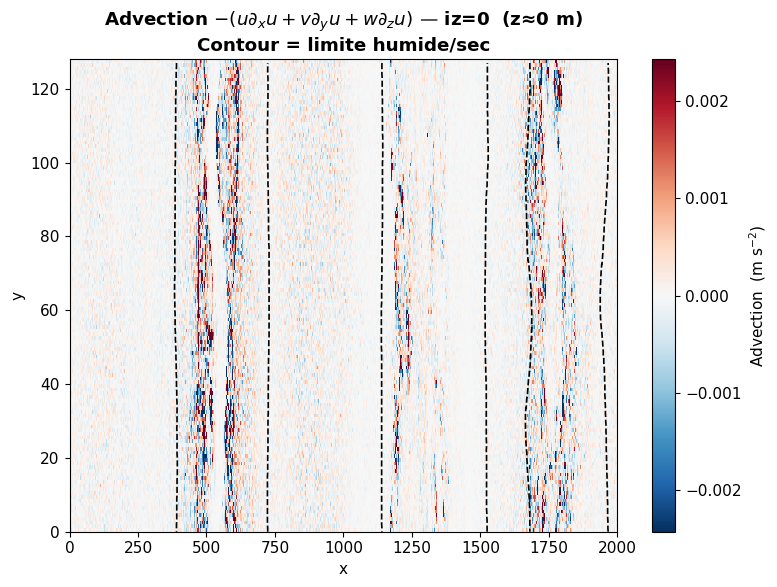

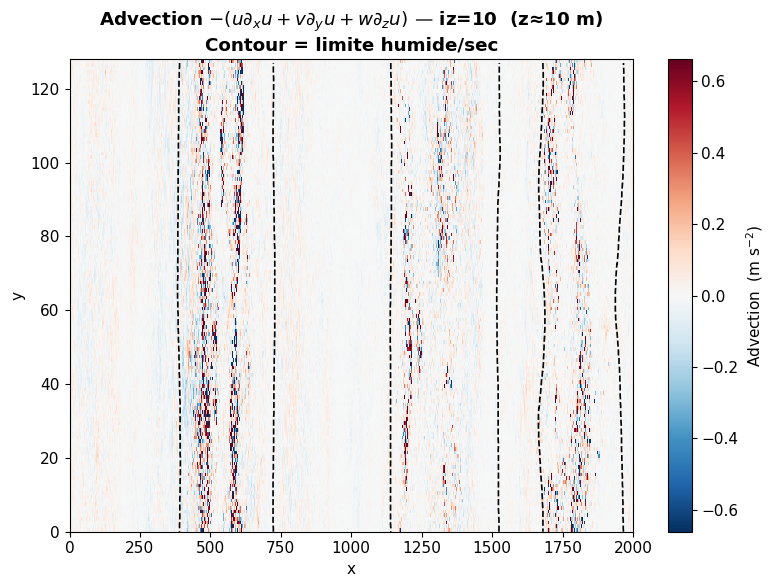

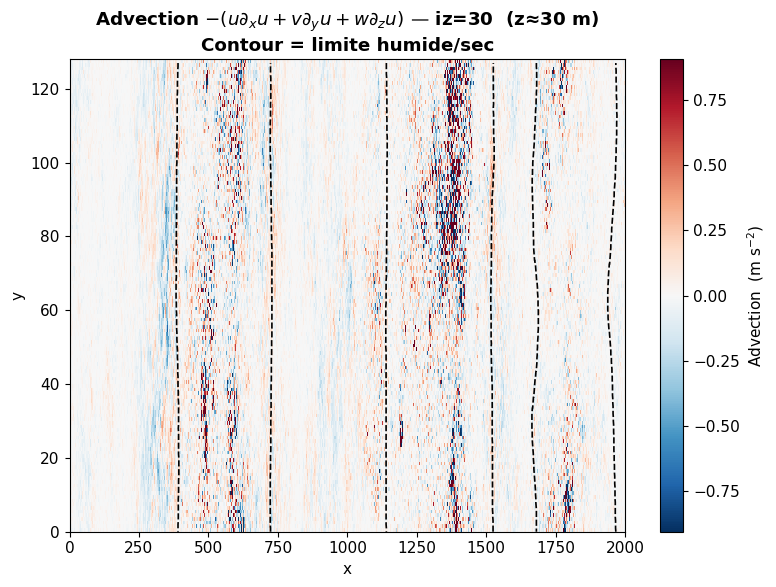

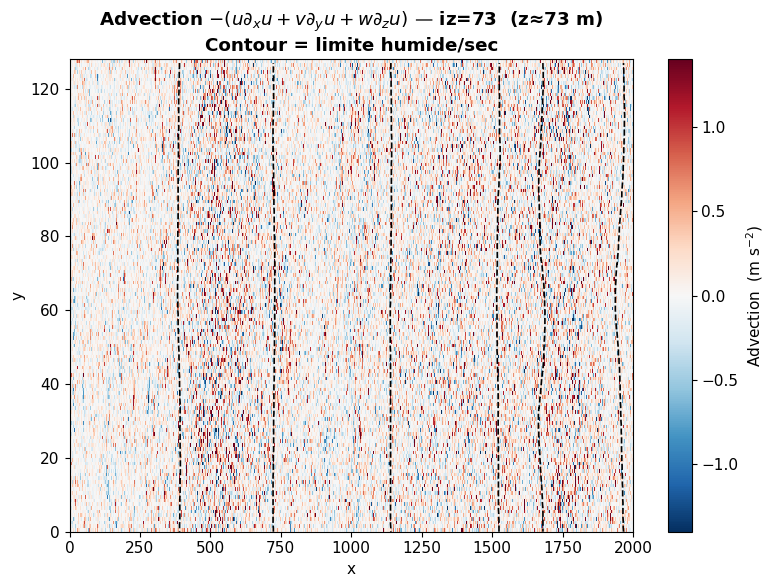

§13.2 Advection terminé.


In [19]:
# ======================================================================
# §13.2 — Terme d'advection  -(u*du/dx + v*du/dy + w*du/dz)
# ======================================================================

ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in IZ_LEVELS:
    u_2d = ds_u['ua'].isel({dim_t: it_c, dim_z: iz}).values   # (ny, nx)
    v_2d = ds_v['va'].isel({dim_t: it_c, dim_z: iz}).values
    w_2d = ds_w['wa'].isel({dim_t: it_c, dim_z: iz}).values

    # Gradients horizontaux (différences finies centrées)
    dudx = np.gradient(u_2d, dx, axis=1)
    dudy = np.gradient(u_2d, dy, axis=0)

    # Gradient vertical centré
    iz_lo = max(iz - 1, 0)
    iz_hi = min(iz + 1, n_z - 1)
    u_lo  = ds_u['ua'].isel({dim_t: it_c, dim_z: iz_lo}).values
    u_hi  = ds_u['ua'].isel({dim_t: it_c, dim_z: iz_hi}).values
    dz    = alt[iz_hi] - alt[iz_lo]
    if dz == 0: dz = alt[1] - alt[0]
    dudz  = (u_hi - u_lo) / dz
    del u_lo, u_hi

    adv_2d = -(u_2d * dudx + v_2d * dudy + w_2d * dudz)   # m/s²
    del u_2d, v_2d, w_2d, dudx, dudy, dudz ; gc.collect()

    fig, ax = plt.subplots(figsize=(8, 6))
    vmax = np.percentile(np.abs(adv_2d), 99)
    if vmax == 0: vmax = 1e-9
    im = ax.pcolormesh(adv_2d, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, label=r'Advection  (m s$^{-2}$)')
    ax.contour(mh.astype(float), levels=[0.5], colors='black',
               linewidths=1.2, linestyles='--')
    ax.set_title(
        rf'Advection $-(u\partial_x u + v\partial_y u + w\partial_z u)$'
        rf' — iz={iz}  (z≈{alt[iz]:.0f} m)'
        '\nContour = limite humide/sec', fontweight='bold')
    ax.set_xlabel('x') ; ax.set_ylabel('y')
    plt.tight_layout() ; plt.show()
    del adv_2d

ds_u.close() ; ds_v.close() ; ds_w.close()
del ds_u, ds_v, ds_w ; gc.collect()
print('§13.2 Advection terminé.')

## Terme de pression à plusieurs niveaux 

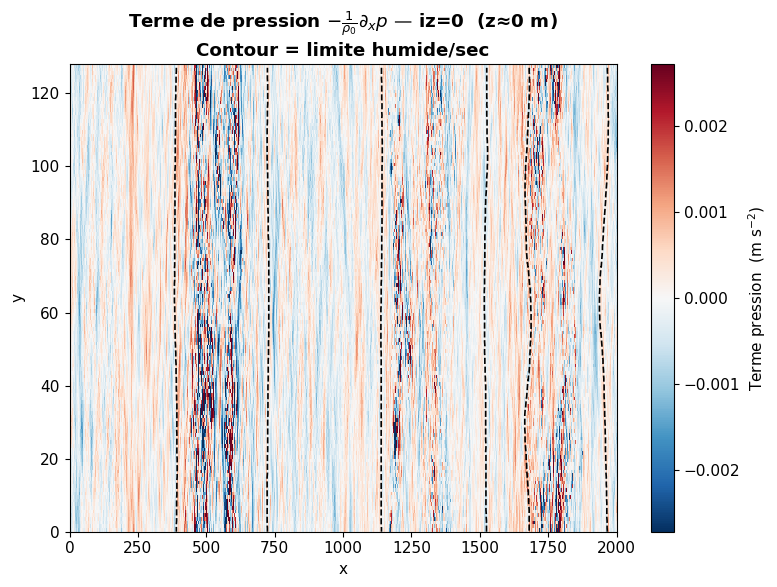

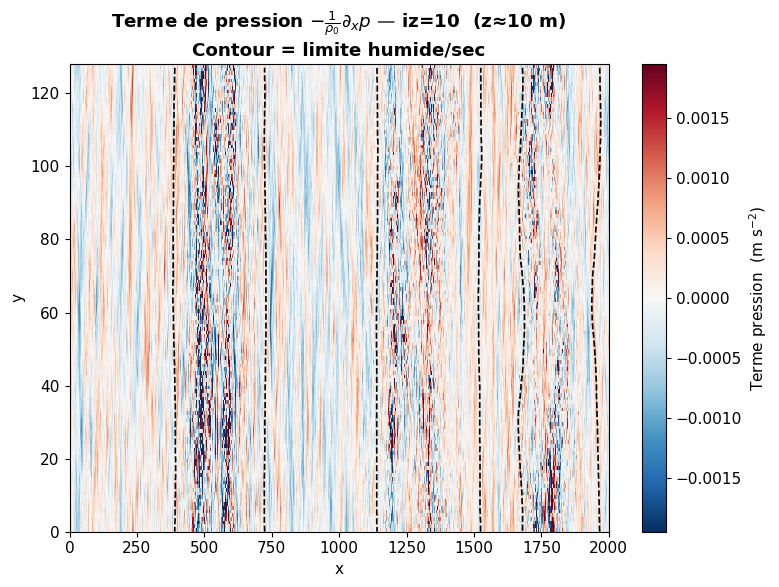

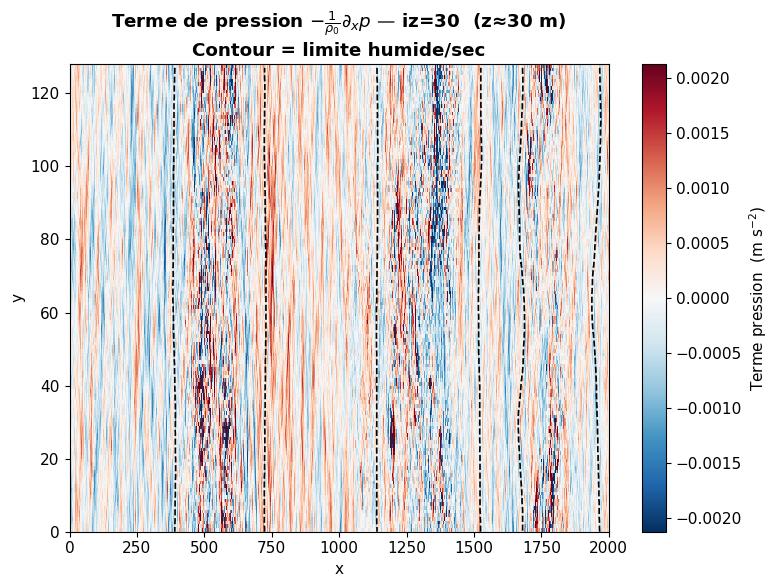

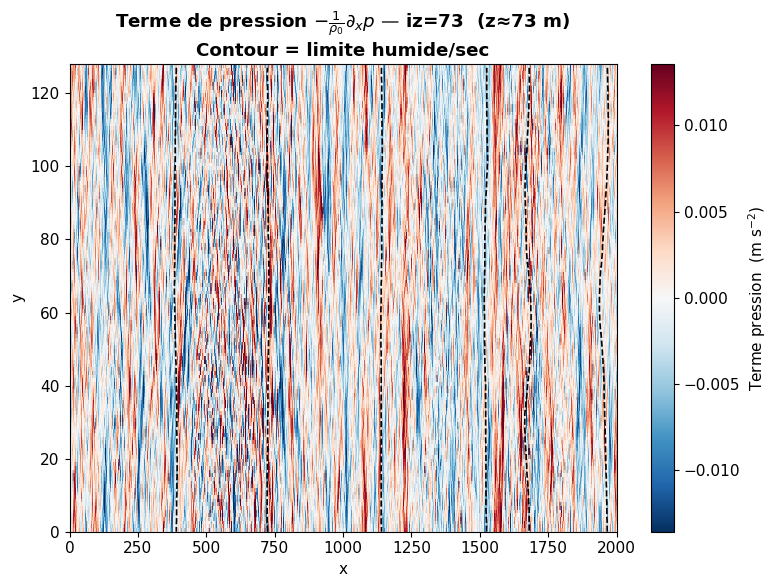

§13.3 Pression terminé.


In [20]:
# ======================================================================
# §13.3 — Terme de pression  -(1/rho0) * dp/dx
# ======================================================================

ds_p = xr.open_dataset(path3d('pa'))

for iz in IZ_LEVELS:
    p_2d    = ds_p['pa'].isel({dim_t: it_c, dim_z: iz}).values   # (ny, nx)
    dpdx    = np.gradient(p_2d, dx, axis=1)
    pres_2d = -dpdx / rho0[iz]   # m/s²
    del p_2d, dpdx ; gc.collect()

    fig, ax = plt.subplots(figsize=(8, 6))
    vmax = np.percentile(np.abs(pres_2d), 99)
    if vmax == 0: vmax = 1e-9
    im = ax.pcolormesh(pres_2d, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, label=r'Terme pression  (m s$^{-2}$)')
    ax.contour(mh.astype(float), levels=[0.5], colors='black',
               linewidths=1.2, linestyles='--')
    ax.set_title(
        rf'Terme de pression $-\frac{{1}}{{\rho_0}}\partial_x p$'
        rf' — iz={iz}  (z≈{alt[iz]:.0f} m)'
        '\nContour = limite humide/sec', fontweight='bold')
    ax.set_xlabel('x') ; ax.set_ylabel('y')
    plt.tight_layout() ; plt.show()
    del pres_2d

ds_p.close() ; del ds_p ; gc.collect()
print('§13.3 Pression terminé.')